In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/customer_data_cleaned.csv")
df.head()

,customer_id,signup_date,age,gender,city,segment,income,purchase_amount,satisfaction_score,age_was_missing,income_was_missing,age_band,signup_year,signup_month,income_band
0,1358,2023-11-11 12:41:50.621242,45.0,Female,Hyderabad,Sme,72734.20,2169.40,1.0,False,False,36-45,2023.0,11.0,High
1,1338,2023-09-14 00:17:18.877755,35.0,Male,Hyderabad,Retail,26311.75,4602.50,2.0,False,False,26-35,2023.0,9.0,Low
2,1328,2023-08-15 18:05:03.006012,34.0,Female,Bangalore,Retail,50911.09,1138.96,1.0,False,False,26-35,2023.0,8.0,Mid
3,1014,2021-02-08 00:51:56.633266,55.0,Male,Mumbai,Retail,39434.56,645.32,2.0,False,False,46-60,2021.0,2.0,Mid
4,1419,2024-05-08 00:08:39.438877,47.0,Male,Mumbai,Sme,64738.33,1674.65,4.0,False,False,46-60,2024.0,5.0,High


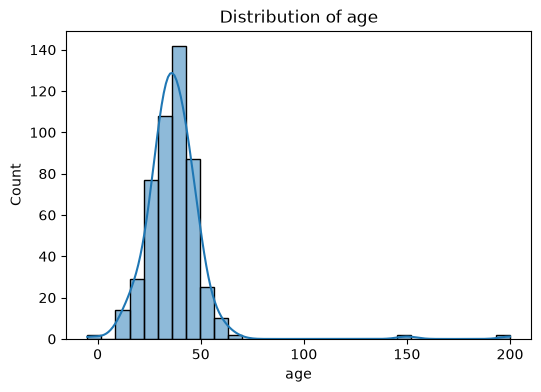

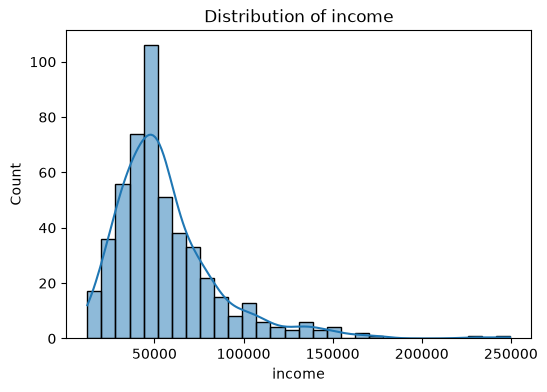

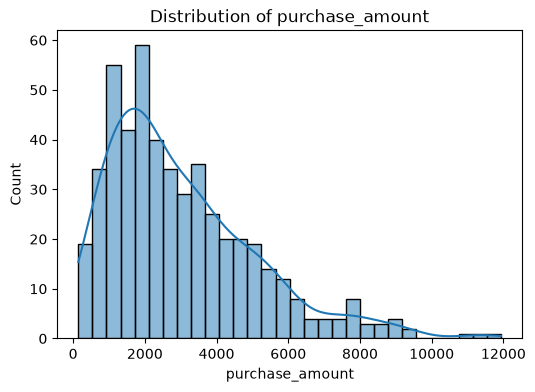

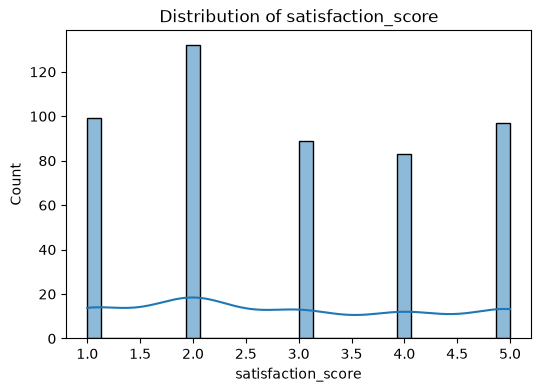

In [2]:
numeric_cols = ['age', 'income', 'purchase_amount', 'satisfaction_score']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()
    

In [9]:

df['age'] = df['age'].where((df['age'] >= 0) & (df['age'] <= 90), df['age'].median())


df['age'].describe()

count    500.000000
mean      36.050000
std        9.884478
min        9.000000
25%       30.000000
50%       36.000000
75%       42.000000
max       67.000000
Name: age, dtype: float64

In [3]:
# Average income by city
df.groupby('city')['income'].mean().sort_values(ascending=False)

city
Delhi        63586.872172
Pune         62038.178171
Bangalore    58088.980380
Kolkata      55474.466837
Mumbai       55253.858866
Hyderabad    50885.140000
Chennai      47567.431038
Name: income, dtype: float64

In [4]:
# Average purchase amount by segment
df.groupby('segment')['purchase_amount'].mean().sort_values(ascending=False)

segment
Corporate    3420.828582
Retail       2938.877296
Sme          2785.270902
Name: purchase_amount, dtype: float64

In [5]:
# Average satisfaction by gender
df.groupby('gender')['satisfaction_score'].mean()

gender
Female    2.900474
Male      2.889273
Name: satisfaction_score, dtype: float64

In [11]:
df.groupby('city')['income'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
city,,
Delhi,63586.872172,99
Pune,62038.178171,41
Bangalore,58088.980380,92
Kolkata,55474.466837,49
Mumbai,55253.858866,97
Hyderabad,50885.140000,69
Chennai,47567.431038,53


In [6]:
df.groupby('segment')['purchase_amount'].agg(['mean', 'count'])

,mean,count
segment,,
Corporate,3420.828582,134
Retail,2938.877296,233
Sme,2785.270902,133


In [10]:
df['segment'] = df['segment'].replace({'Sme': 'SME'})
df['segment'].value_counts()

segment
Retail       233
Corporate    134
SME          133
Name: count, dtype: int64

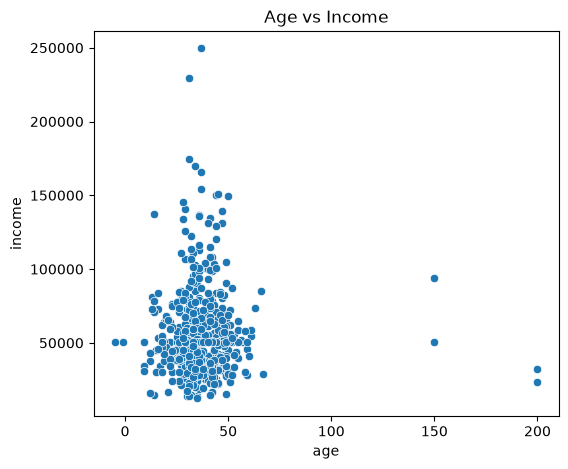

In [7]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='age', y='income')
plt.title('Age vs Income')
plt.show()

In [12]:
df['age'].corr(df['income'])

np.float64(0.020239573736603483)

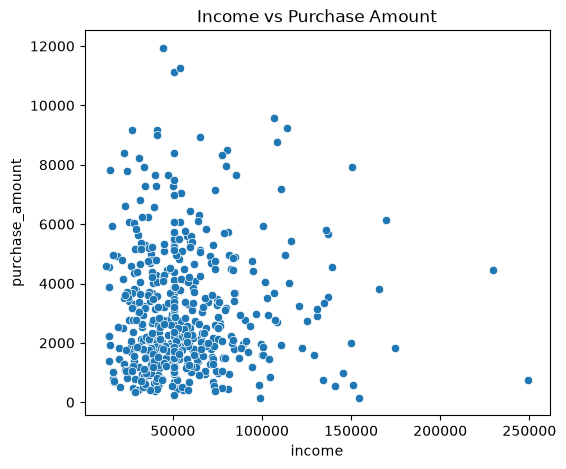

In [8]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='income', y='purchase_amount')
plt.title('Income vs Purchase Amount')
plt.show()

In [13]:
df['income'].corr(df['purchase_amount'])

np.float64(0.03053438396992541)

In [ ]:
## Candidate Insights & Follow-Up Questions

**1. Insight:** Age data still contained extreme outlier values (150, 200, -5) even after Task 4 cleaning, because Task 4 only handled missing values, not invalid ones.
**Question:** Should Task 4's transformation script be updated with an explicit valid-range check for age, so this doesn't slip through again on fresh data?

**2. Insight:** Income and purchase_amount distributions are right-skewed (most customers cluster low/moderate, a smaller group pulls the tail higher).
**Question:** Should reporting use median alongside mean for these columns, so a "typical" customer isn't misrepresented by high-spending outliers?

**3. Insight:** Satisfaction score of "2" is the single most common rating — even more common than "5" — which is mildly unusual.
**Question:** Is this concentrated in a specific city or segment, or spread evenly? Would need a groupby of satisfaction by segment/city to find out.

**4. Insight:** Delhi has the highest average income (₹63,587, n=99) and Chennai the lowest (₹47,567, n=53) — a real, sample-size-backed gap across cities.
**Question:** Does this income gap actually translate into a spending gap by city, or does segment override it (as seen in finding 5)?

**5. Insight:** Purchase amount differs meaningfully by segment — Corporate (~₹3,421) > Retail (~₹2,939) > SME (~₹2,785) — but income and age show almost no correlation with purchase amount (0.02 and 0.03).
**Question:** What about Corporate customers specifically drives higher spending, if not income or age? Would need more data (purchase frequency, product type) to dig further.

**6. Insight:** Gender shows essentially no difference in satisfaction score (2.90 vs 2.89) — a legitimate "no effect found" result.
**Question:** None needed — this rules gender out as a factor worth pursuing for satisfaction-related questions.

**7. Process note:** A visual "upward trend" in two scatter plots (age vs income, income vs purchase_amount) did NOT match the actual correlation values (both near 0). This was a useful reminder to always confirm visual impressions with a numeric correlation check before writing down a finding.

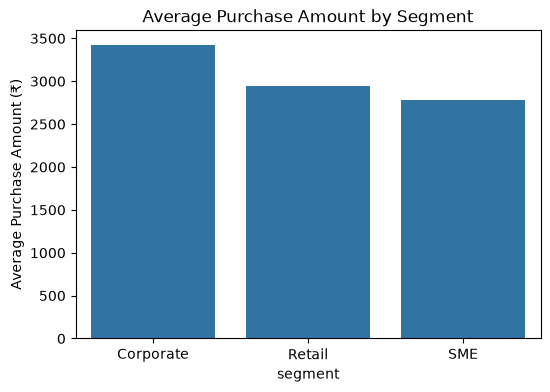

In [14]:
# Chart 1: Purchase amount by segment 
plt.figure(figsize=(6,4))
segment_avg = df.groupby('segment')['purchase_amount'].mean().sort_values(ascending=False)
sns.barplot(x=segment_avg.index, y=segment_avg.values, order=segment_avg.index)
plt.title('Average Purchase Amount by Segment')
plt.ylabel('Average Purchase Amount (₹)')
plt.show()

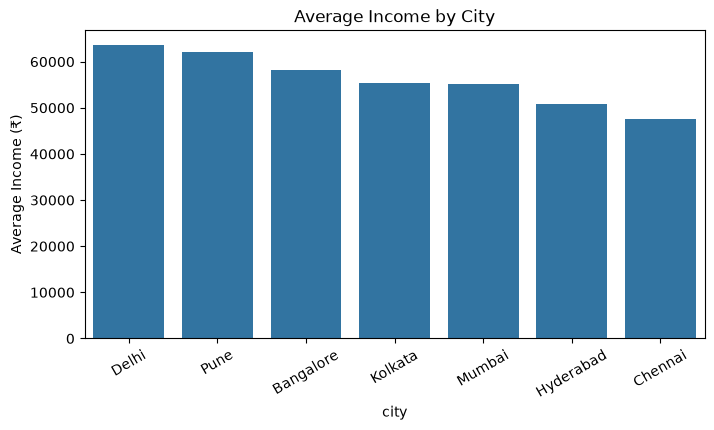

In [15]:
# Chart 2: Average income by city
plt.figure(figsize=(8,4))
city_avg = df.groupby('city')['income'].mean().sort_values(ascending=False)
sns.barplot(x=city_avg.index, y=city_avg.values, order=city_avg.index)
plt.title('Average Income by City')
plt.ylabel('Average Income (₹)')
plt.xticks(rotation=30)
plt.show()

## Summary: Key Charts & Takeaways

**1. Purchase Amount by Segment** — Corporate customers spend ~23% more on average (₹3,421) than SME customers (₹2,785), despite income/age showing no correlation with spending. Segment, not income, appears to be the stronger driver of purchase behavior.

**2. Average Income by City** — Delhi (₹63,587) and Pune (₹62,038) have the highest average customer income; Chennai (₹47,567) the lowest. All cities have solid sample sizes (41-99 customers), so this gap is reliable, not noise.

**3. Satisfaction Score Distribution** — Score "2" is unexpectedly the most common rating (130+ customers), ahead of even score "5". Worth investigating further by segment/city before drawing conclusions.

**4. Income Distribution (post-cleaning)** — Confirms the Task 4 fix worked: the ₹10,000,000 placeholder outlier identified in Task 2 is gone, and the distribution now shows a realistic right-skewed shape peaking around ₹40,000-50,000.